In [1]:
from spin_lattices import KagomeLattice
import lattice_symmetries as ls
import scipy.sparse.linalg
from heisenberg_hamiltonians import HeisenbergJ1J2


2023-02-13 17:58:42.062 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-02-13 17:58:42.065 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
2023-02-13 17:58:42.133 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
[Debug]   [LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


In [2]:
lat = KagomeLattice(width=2, height=2)


<AxesSubplot: xlabel='emb_x', ylabel='emb_y'>

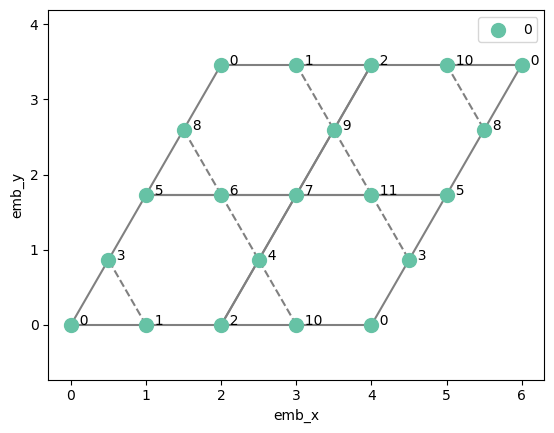

In [3]:
lat.plot()


In [4]:
lat.edges_to_kind

{(0, 1): 1,
 (1, 2): 1,
 (0, 3): 1,
 (1, 3): 2,
 (3, 5): 1,
 (5, 6): 1,
 (6, 4): 2,
 (6, 7): 1,
 (4, 7): 1,
 (2, 4): 1,
 (5, 8): 1,
 (6, 8): 2,
 (8, 0): 1,
 (1, 9): 2,
 (9, 2): 1,
 (7, 9): 1,
 (2, 10): 1,
 (10, 0): 1,
 (10, 4): 2,
 (7, 11): 1,
 (11, 3): 2,
 (11, 5): 1,
 (11, 9): 2,
 (10, 8): 2}

In [5]:
def filter_automorphism(automorphisms, conditions):
    """Filter automorphisms based on conditions."""
    for automorphism in automorphisms:
        if all(automorphism[k] == v for k, v in conditions.items()):
            yield automorphism


In [6]:
def one(iter):
    """Return the first element of an iterator. Guarantee that there is only one element."""
    try:
        first = next(iter)
    except StopIteration:
        return None
    try:
        next(iter)
    except StopIteration:
        return first
    raise ValueError("More than one element.")
    

In [7]:
lat.get_automorphisms()


[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [0, 3, 5, 1, 6, 2, 4, 7, 10, 11, 8, 9],
 [0, 8, 5, 10, 11, 2, 9, 7, 1, 6, 3, 4],
 [0, 10, 2, 8, 9, 5, 11, 7, 3, 4, 1, 6],
 [2, 1, 0, 9, 8, 7, 6, 5, 4, 3, 10, 11],
 [2, 4, 7, 10, 11, 0, 3, 5, 1, 6, 9, 8],
 [2, 9, 7, 1, 6, 0, 8, 5, 10, 11, 4, 3],
 [2, 10, 0, 4, 3, 7, 11, 5, 9, 8, 1, 6],
 [5, 3, 0, 11, 10, 7, 4, 2, 6, 1, 8, 9],
 [5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 11, 10],
 [5, 8, 0, 6, 1, 7, 9, 2, 11, 10, 3, 4],
 [5, 11, 7, 3, 4, 0, 10, 2, 8, 9, 6, 1],
 [7, 4, 2, 6, 1, 5, 3, 0, 11, 10, 9, 8],
 [7, 6, 5, 4, 3, 2, 1, 0, 9, 8, 11, 10],
 [7, 9, 2, 11, 10, 5, 8, 0, 6, 1, 4, 3],
 [7, 11, 5, 9, 8, 2, 10, 0, 4, 3, 6, 1]]

In [8]:
top_shift = one(filter_automorphism(lat.get_automorphisms(), {0: 5, 1: 6}))


In [9]:
right_shift = one(filter_automorphism(lat.get_automorphisms(), {0: 2, 3: 4}))


In [10]:
top_shift

[5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 11, 10]

In [11]:
right_shift

[2, 10, 0, 4, 3, 7, 11, 5, 9, 8, 1, 6]

In [12]:
symmetries = ls.Symmetries([ls.Symmetry(right_shift, sector=0), ls.Symmetry(top_shift, sector=0)])


In [13]:
J1 = 1
J2 = 0.8

# Constructing the Hamiltonian
expr_str = "2 (σ⁺₀ σ⁻₁ + σ⁺₁ σ⁻₀) + σᶻ₀ σᶻ₁"

# fmt: off
expr = (J1 * ls.Expr(expr_str, sites=lat.kind_to_edges[1]) + 
        J2 * ls.Expr(expr_str, sites=lat.kind_to_edges[2]))
# fmt: on


In [15]:
def get_ground_state(symmetries):
    basis = ls.SpinBasis(
        number_spins=lat.number_spins,
        symmetries=symmetries,
        hamming_weight=lat.number_spins // 2,
        spin_inversion=None,
    )
    basis.build()
    hamiltonian = ls.Operator(basis, expr)
    return scipy.sparse.linalg.eigsh(hamiltonian, k=1, which="SA")


In [16]:
get_ground_state(
    ls.Symmetries([
                   ls.Symmetry([0, 3, 5, 1, 6, 2, 4, 7, 10, 11, 8, 9], sector=1)])
)[0]


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


array([-20.43659595])

In [17]:
get_ground_state(
    ls.Symmetries([])
)[0]


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


array([-20.43659595])

In [19]:
system = HeisenbergJ1J2(KagomeLattice(height=2, width=4), J1, J2, use_symmetries=True, spin_inversion=None)


2023-02-13 18:00:58.476 | DEBUG    | heisenberg_hamiltonians:__init__:398 - number_spins=24
2023-02-13 18:00:58.483 | DEBUG    | heisenberg_hamiltonians:__init__:408 - Symmetry group contains 16 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-02-13 18:00:58.677 | DEBUG    | heisenberg_hamiltonians:__init__:417 - Hilbert space dimension is 170028
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


In [20]:
system.basis.index(system.basis.states)

array([     0,      1,      2, ..., 170025, 170026, 170027])

In [25]:
automorphisms = lat.get_automorphisms()
for i in range(len(automorphisms) + 1):
    print(
        i,
        get_ground_state(
            ls.Symmetries(
                [ls.Symmetry(automorphism, sector=0) for automorphism in automorphisms[:i]]
            )
        )[0],
    )


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


0 [-20.43659595]


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


1 [-20.43659595]


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


...

14 [-20.03822982]


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


15 [-20.03822982]


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


16 [-20.03822982]


In [26]:
automorphisms[:2]

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [0, 3, 5, 1, 6, 2, 4, 7, 10, 11, 8, 9]]